# Fibre Photometry Trace Analysis: RRM003 and RRM004

**Objective:** align fibre photometry (FP) traces to key task events (offer tone, entry, accept, exit) and compare signal dynamics across outcome types (rewarded, reject, quit) and offer levels.

**Method:** classify every trial in the behaviour log into an outcome (`classify_events`, see `fp_functions/helper_functions.py`), pull the matching FP recording, and average traces aligned to the event of interest across trials. The final section (Presentation Figures) reproduces the two headline overlay plots split by hemisphere.


## Setup (shared across the RRM003/RRM004 notebooks)

This repeats the imports and data-loading cells common to every RRM003/RRM004 notebook, so each one runs standalone rather than depending on cells left over in a different notebook. **Update the file paths below** to point at your own copy of the data (either the lab server path shown, or the `Data/` folder bundled in this repo).


In [1]:
#import packages

import numpy as np
import pandas as pd
from matplotlib import pyplot as plt
import seaborn as sns
import os
import re
import matplotlib as mpl
from matplotlib import rc
from scipy import signal
from IPython.core.debugger import set_trace

#import behaviour functions
from main import *
from behaviour_functions.helper_functions import *
from behaviour_functions.plotting_functions import *

# import FP functions
from fp_functions.helper_functions import *
from fp_functions.plotting_fp import *
from fp_functions.utils_albert import *

CaImAn not installed or environment not activated, certain functions might not be usable


In [2]:
# load sessions for each mouse

# data paths - NOTE: change this to correct path based on computer using
fp_folder_RRMM003 = '/Volumes/Wilbrecht_file_server/LauraG/RR_FP_Data/RRM003'
behavior_folder_RRMM003 = '/Volumes/Wilbrecht_file_server/LauraG/RR_Behavior_Data/RRM003'

fp_folder_RRMM004 = '/Volumes/Wilbrecht_file_server/LauraG/RR_FP_Data/RRM004'
behavior_folder_RRMM004 = '/Volumes/Wilbrecht_file_server/LauraG/RR_Behavior_Data/RRM004'

# load behaviour data
bdata_RM0003 = load_behavior_FP(behavior_folder_RRMM003)
bdata_RM0004 = load_behavior_FP(behavior_folder_RRMM004)


## Task Details

_Goal_: plot FP traces aligned to different event types for different outcome types (conditions)


### Condition Types

- `reject`: left turn, reject offer
- `quit`: right turn, quit before reward tone
- `rewarded`: right turn accept, reward offered and taken

### Alignment Types

- `offer_tone_x`: align to particular offer tone
- `entry`: align to sharp entry
- `accept`: align to sharp accept 
- `exit`: align to sharp exit 

### Plotting Function Parameters 
Note: for more information look at documentation for `grab_fp_traces` in fp_functions.helper_functions


_Parameters_:
- alignment: fp traces aligned to this time stamp
    - options -> 'offer_tone', offer_tone_0', 'entry', 'accept', 'exit'
        - if looking at condition = reject, can only align to entry or exit
        - note: aligning to 'offer_tone_0' will only keep 0 offer tone rejects, discard others
- channel: recording channel for FP
    - options -> 'green', 'red', 'control'
- side: hemisphere recording from
    - options -> 'left', 'right'
- condition: condition to plot
    - options -> 'all', 'rewarded', 'reject', 'quit'
- trigger_mode: triggering mode for neurophotometrics system
    - options -> 'TRIG1', 'TRIG3'
- baseline_method: methods for baseline substraction and z-scoring vs dF/F
    - options -> 'med_filter', 'robust_fast', 'mode', 'isobestic'
- split: split fp_traces into different sub-groups
    - options -> 'restaurant', 'offer_tone', 'none', 'all' for seperate plots
    - options --> 'all_restaurant', 'all_offer_tone' for overlayed plots
    
    

In [9]:
## Get Data RR
animal = 'RRM004'
day = 158
fp_folder = fp_folder_RRMM004
behavior_folder = behavior_folder_RRMM004

behaviour_summary, data_rr, data_fp = get_data_rr(fp_folder, behavior_folder, animal, day)

/Volumes/Wilbrecht_file_server/LauraG/RR_FP_Data/RRM004/FP_Dayp158_epoch-5_ID-RRM004_2021-04-26T14_59_40.csv
Pellets Revealed R1: 25
Pellets Eaten R1: 25
Number of 0% Offer Tone Rejections: 8
Pellets Revealed R2: 23
Pellets Eaten R2: 22
Number of 0% Offer Tone Rejections: 15
Pellets Revealed R3: 15
Pellets Eaten R3: 15
Number of 0% Offer Tone Rejections: 27
Pellets Revealed R4: 19
Pellets Eaten R4: 17
Number of 0% Offer Tone Rejections: 27
Percentage of No Offer Rejections: 0.4426229508196721


In [10]:
# Load FP Trace to Compare
alignment = 'offer_tone'
condition = 'reject'
channel = 'green'
side = 'left'
trigger_mode = 'TRIG1'
baseline_method = 'robust_fast'
split = 'none'


signals_left_control, t_left = get_fp_aligned_traces(alignment, 'control', 'left', condition, data_fp, data_rr, trigger_mode, baseline_method, split)
signals_right_control, t_right = get_fp_aligned_traces(alignment, 'control', 'right', condition, data_fp, data_rr, trigger_mode, baseline_method, split)
signals_left, t_left = get_fp_aligned_traces(alignment, channel, 'left', condition, data_fp, data_rr, trigger_mode, baseline_method, split)
signals_right, t_right = get_fp_aligned_traces(alignment, channel, 'right', condition, data_fp, data_rr, trigger_mode, baseline_method, split)

Restaurant 4 has no traces for reject condition at probability tone 0
Restaurant 4 has no traces for reject condition at probability tone 20
Restaurant 4 has no traces for reject condition at probability tone 80
Restaurant 4 has no traces for reject condition at probability tone 100
Restaurant 4 has no traces for reject condition at probability tone 0
Restaurant 4 has no traces for reject condition at probability tone 20
Restaurant 4 has no traces for reject condition at probability tone 80
Restaurant 4 has no traces for reject condition at probability tone 100
Restaurant 2 has no traces for reject condition at probability tone 0
Restaurant 2 has no traces for reject condition at probability tone 20
Restaurant 2 has no traces for reject condition at probability tone 80
Restaurant 2 has no traces for reject condition at probability tone 100
Restaurant 4 has no traces for reject condition at probability tone 0
Restaurant 4 has no traces for reject condition at probability tone 20
Restaur

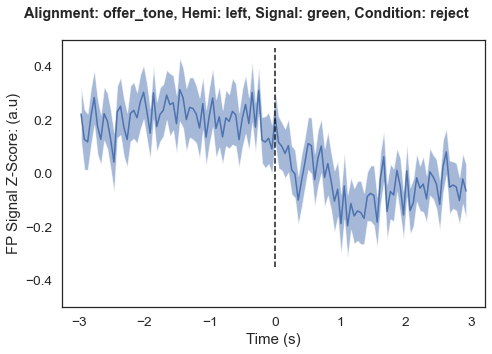

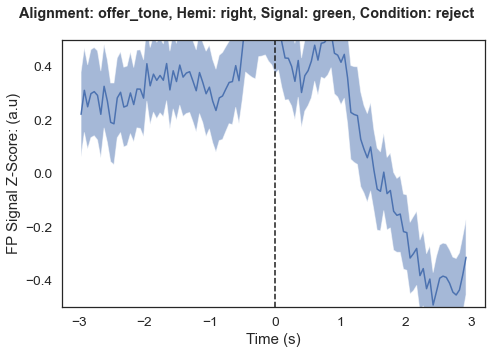

In [11]:
# Plot FP Traces
plot_opt = 'none'
y_min=-0.5
y_max=0.5

plot_trial_avg_FP_aligned(signals_left, t_left, plot_opt, alignment, 'left', channel, condition, baseline_method)
plt.ylim(y_min,y_max)
plot_trial_avg_FP_aligned(signals_right, t_right, plot_opt, alignment, 'right', channel, condition, baseline_method)
plt.ylim(y_min,y_max)
plt.show()

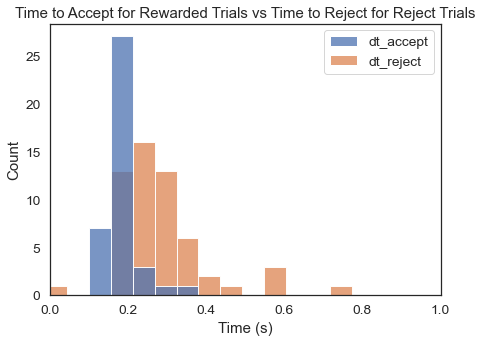

In [26]:
# Plot dt Histogram
plot_dt_hist(behaviour_summary['dt_choice'])

## Presentation Figures

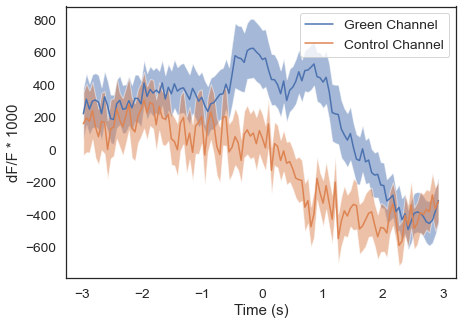

In [13]:
# Plot Overlayed - RIGHT 

sns.set_theme(style="white", context="notebook", palette='deep', font_scale=1.25)
mean_trace_ctrl = np.mean(signals_right_control*1000, axis = 0)
SEM_trace_ctrl = np.std(signals_right_control*1000, axis=0)/np.sqrt(len(signals_right_control))
mean_trace_green = np.mean(signals_right*1000, axis = 0)
SEM_trace_green = np.std(signals_right*1000, axis=0)/np.sqrt(len(signals_right))


plt.plot(t_right, mean_trace_green, label = 'Green Channel')
plt.fill_between(t_right, mean_trace_green + SEM_trace_green,mean_trace_green - SEM_trace_green, alpha=0.5)
plt.plot(t_right, mean_trace_ctrl, label = 'Control Channel')
plt.fill_between(t_right, mean_trace_ctrl + SEM_trace_ctrl,mean_trace_ctrl - SEM_trace_ctrl, alpha=0.5)


ymin, ymax = -0.5,0.5
plt.plot([0, 0], [ymin, ymax], '--k')

plt.xlabel('Time (s)')
plt.ylabel('dF/F * 1000')
plt.legend()

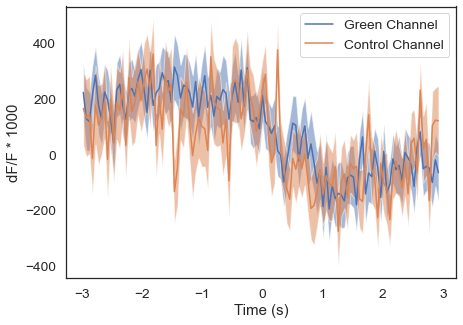

In [14]:
# Plot Overlayed - LEFT

sns.set_theme(style="white", context="notebook", palette='deep', font_scale=1.25)
mean_trace_ctrl = np.mean(signals_left_control*1000, axis = 0)
SEM_trace_ctrl = np.std(signals_left_control*1000, axis=0)/np.sqrt(len(signals_left_control))
mean_trace_green = np.mean(signals_left*1000, axis = 0)
SEM_trace_green = np.std(signals_left*1000, axis=0)/np.sqrt(len(signals_left))


plt.plot(t_left, mean_trace_green, label = 'Green Channel')
plt.fill_between(t_left, mean_trace_green + SEM_trace_green,mean_trace_green - SEM_trace_green, alpha=0.5)
plt.plot(t_left, mean_trace_ctrl, label = 'Control Channel')
plt.fill_between(t_left, mean_trace_ctrl + SEM_trace_ctrl,mean_trace_ctrl - SEM_trace_ctrl, alpha=0.5)


ymin, ymax = -0.5,0.5
plt.plot([0, 0], [ymin, ymax], '--k')

plt.xlabel('Time (s)')
plt.ylabel('dF/F * 1000')
plt.legend()